In [1]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
import cv2
import matplotlib.pyplot as plt
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 載入預訓練 Faster R-CNN
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
num_classes = 2  # 0是保留給背景，1、2、3是實際類別
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [2]:
# 裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ====== 混合精度訓練和梯度累計設置 ======
scaler = torch.amp.GradScaler('cuda')  # 用於混合精度訓練的梯度縮放器
accumulation_steps = 4  # 每隔 4 個 mini-batch 進行一次優化器更新
# ===========================================

In [3]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    #A.GaussNoise(p=0.3),
    #A.RandomScale(scale_limit=0.2, p=0.4),
    A.Rotate(limit=15, p=0.3),
], bbox_params=A.BboxParams(format='pascal_voc',label_fields=['labels'],min_visibility=0.3))

In [4]:
# 資料集
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, picture_folder, label_folder):
        self.picture_folder = picture_folder
        self.label_folder = label_folder
        self.image_files = [f for f in os.listdir(picture_folder)
                           if f.endswith(('.jpg', '.png'))]

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.picture_folder, img_name)
        label_path = os.path.join(self.label_folder, os.path.splitext(img_name)[0] + '.txt')

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = F.to_tensor(img_rgb)

        # 讀取 YOLO 格式標註（class_id center_x center_y width height）
        boxes = []
        labels = []
        img_height, img_width = img.shape[:2]

        #資料增強
        transformed = transform(image=img_rgb,bboxes=boxes,labels=labels)
        img_rgb = transformed['image']
        boxes   = list(transformed['bboxes'])
        labels  = list(transformed['labels'])

        with open(label_path, 'r') as f:
            for line in f:
                data = line.strip().split()
                class_id = int(data[0])
                # 將標註檔案中的 class_id 轉換為模型需要的格式
                labels.append(class_id + 1)

                # 正規化座標轉像素座標
                cx, cy, w, h = map(float, data[1:5])
                xmin = int((cx - w / 2) * img_width)
                ymin = int((cy - h / 2) * img_height)
                xmax = int((cx + w / 2) * img_width)
                ymax = int((cy + h / 2) * img_height)
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        targets = {"boxes": boxes, "labels": labels}

        return tensor, targets

    def __len__(self):
        return len(self.image_files)

# 資料集和 dataloader
dataset = CustomDataset(picture_folder='./images',label_folder='./labels')

def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(dataset, batch_size=3, shuffle=True, collate_fn=collate_fn)

# 訓練
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)
num_epochs = 60
train_loss = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # ====== 混合精度訓練: 使用 autocast 包裹前向傳播和損失計算 ======
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            # 將損失按累計步數縮放，以保持梯度平均值正確
            scaled_losses = losses / accumulation_steps
        # =============================================================

        # ====== 混合精度訓練: 使用 scaler 進行後向傳播 ======
        scaler.scale(scaled_losses).backward()
        # ==================================================

        # ====== 梯度累計: 每達到指定步數才更新一次模型參數 ======
        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        # ====================================================

        epoch_loss += losses.item()

    # 處理最後一個 epoch 中可能剩餘的梯度 (如果 dataloader 長度不是 accumulation_steps 的倍數)
    if (len(dataloader) % accumulation_steps != 0):
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    avg_loss = epoch_loss / len(dataloader)
    train_loss.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

# 類別對應字典（用於後續推論時使用）
class_names = {
    0: 'background',
    1: 'bubble'
}

Epoch 1/60, Average Loss: 6.0106
Epoch 2/60, Average Loss: 2.6518
Epoch 3/60, Average Loss: 1.5978
Epoch 4/60, Average Loss: 1.5519
Epoch 5/60, Average Loss: 1.2973
Epoch 6/60, Average Loss: 1.2516
Epoch 7/60, Average Loss: 1.2286
Epoch 8/60, Average Loss: 1.1528
Epoch 9/60, Average Loss: 1.0636
Epoch 10/60, Average Loss: 1.0050
Epoch 11/60, Average Loss: 1.0228
Epoch 12/60, Average Loss: 1.0714
Epoch 13/60, Average Loss: 1.0296
Epoch 14/60, Average Loss: 1.1701
Epoch 15/60, Average Loss: 0.9859
Epoch 16/60, Average Loss: 0.9388
Epoch 17/60, Average Loss: 0.8814
Epoch 18/60, Average Loss: 0.9039
Epoch 19/60, Average Loss: 0.8624
Epoch 20/60, Average Loss: 0.8496
Epoch 21/60, Average Loss: 0.8338
Epoch 22/60, Average Loss: 0.8580
Epoch 23/60, Average Loss: 0.8598
Epoch 24/60, Average Loss: 0.8679
Epoch 25/60, Average Loss: 0.8430
Epoch 26/60, Average Loss: 0.8526
Epoch 27/60, Average Loss: 0.8542
Epoch 28/60, Average Loss: 0.8297
Epoch 29/60, Average Loss: 0.8698
Epoch 30/60, Average Lo

Model predictions:
檢測到 83 個物體
信心分數: tensor([0.9011, 0.8695, 0.8566, 0.8434, 0.8424, 0.8327, 0.8248, 0.8199, 0.8129,
        0.7912, 0.7904, 0.7892, 0.7871, 0.7823, 0.7778, 0.7552, 0.7422, 0.7412,
        0.7362, 0.7299, 0.7292, 0.7290, 0.7284, 0.7247, 0.7193, 0.7176, 0.7057,
        0.6950, 0.6890, 0.6845, 0.6735, 0.6709, 0.6648, 0.6632, 0.6611, 0.6529,
        0.6419, 0.6279, 0.6275, 0.6271, 0.6267, 0.6162, 0.6160, 0.6133, 0.6109,
        0.6041, 0.5959, 0.5825, 0.5749, 0.5688, 0.5594, 0.5503, 0.5487, 0.5463,
        0.5449, 0.5294, 0.5222, 0.5070, 0.5035, 0.5005, 0.4916, 0.4667, 0.4319,
        0.4050, 0.4000, 0.3749, 0.3686, 0.3664, 0.3604, 0.3466, 0.3454, 0.3361,
        0.3191, 0.2856, 0.2827, 0.1989, 0.1734, 0.1696, 0.1524, 0.1380, 0.0909,
        0.0656, 0.0566], device='cuda:0')
標籤: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

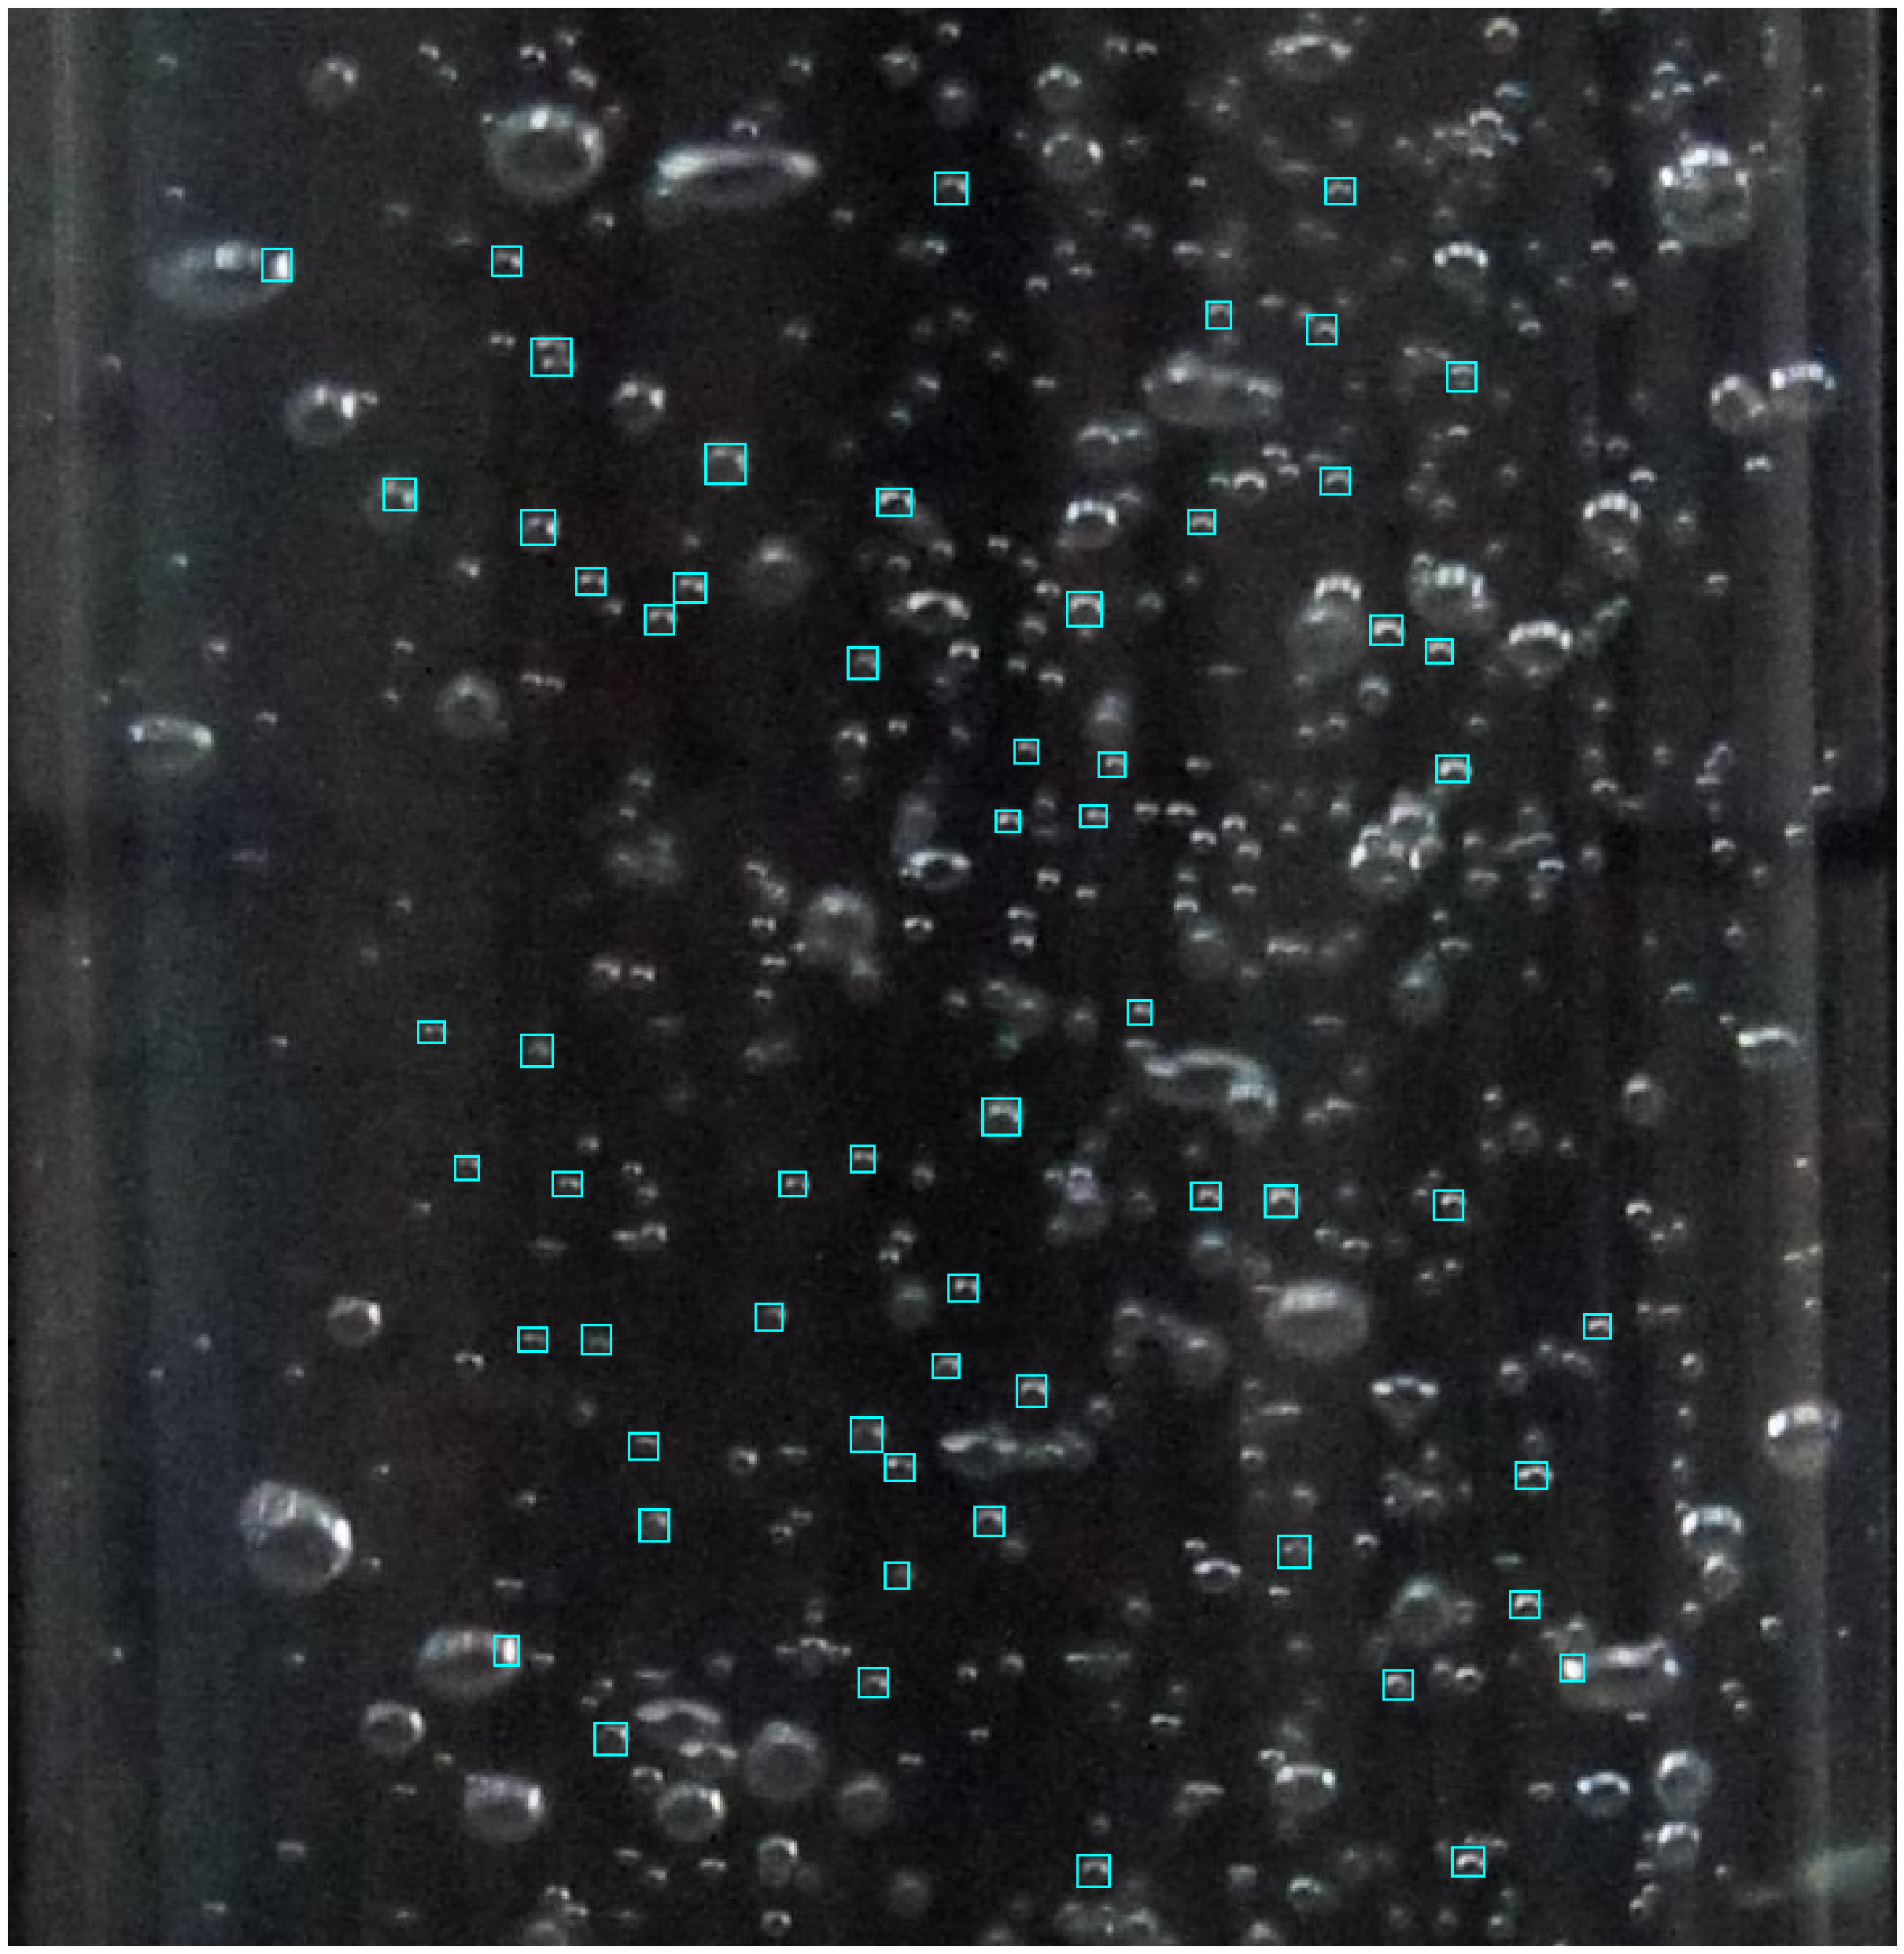

In [5]:
model.eval()
img_path = "./images/0fa9695a-DSC01076cut.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(img_rgb).to(device)

with torch.no_grad():
    prediction = model([tensor])

print("Model predictions:")
print(f"檢測到 {len(prediction[0]['boxes'])} 個物體")
print(f"信心分數: {prediction[0]['scores']}")
print(f"標籤: {prediction[0]['labels']}")

# 修正後的類別對應 (與訓練階段的 class_id + 1 對應一致)
class_names = {
    1: 'citric', # 原始 YOLO class_id 0
}

# 畫框
output = img_rgb.copy()
threshold = 0.5
colors = {
    1: (0, 255, 255),   # citric → 黃綠色
}

count = 0
for box, score, label in zip(prediction[0]['boxes'],
                             prediction[0]['scores'],
                             prediction[0]['labels']):
    if score > threshold:
        count += 1
        label_name = class_names.get(label.item(), 'unknown')
        color = colors.get(label.item(), (255, 255, 255))  # 預設白色
        x1, y1, x2, y2 = box.int().tolist()

        # 畫框
        cv2.rectangle(output, (x1, y1), (x2, y2), color, 1)

        # 顯示標籤文字
        #text = f"{label_name}: {score:.2f}"
        #cv2.putText(output, text, (x1, max(y1 - 10, 20)),
                    #cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

print(f"顯示 {count} 個框（閾值: {threshold}）")
plt.figure(figsize=(48, 32))
plt.imshow(output)
plt.axis("off")
plt.show()

In [6]:
torch.save(model.state_dict(), './bubble_260604-3.pth')

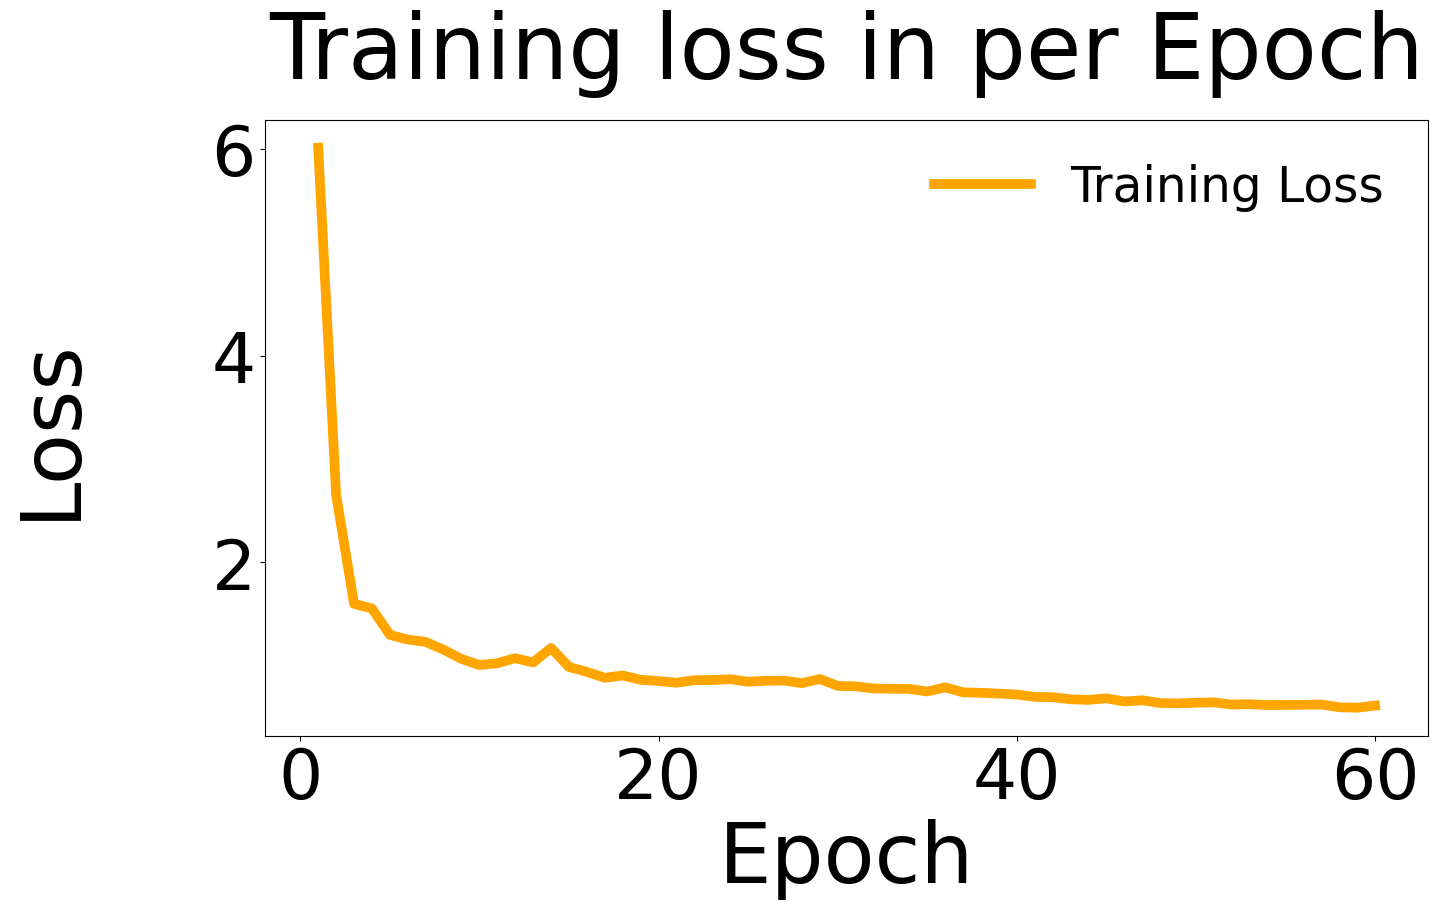

In [10]:
import numpy as np
plt.rcParams.update({
  'axes.titlesize': 65,       # 圖表標題字體大小
  'axes.labelsize': 60,       # 座標軸標籤字體大小
  'xtick.labelsize': 50,       # X 軸刻度字體大小
  'ytick.labelsize': 50,       # Y 軸刻度字體大小
  'legend.fontsize': 35,       # 圖例字體大小
})

fig, ax = plt.subplots(figsize=(15, 8))
plt.plot(range(1, num_epochs + 1), train_loss, label='Training Loss', color='orange', linewidth=7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
ax.yaxis.set_label_coords(-0.15, 0.5) # Y軸標題位置
plt.title('Training loss in per Epoch', pad=30)
plt.legend(frameon=False)
#plt.grid(True)
#plt.ylim(0,8)
#ax.set_yticks(np.arange(0.5, 1.5, 0.5)) # Y軸級距，0~1.3每個0.4標一次
plt.show()